**06_EfficientNetB0**

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from tensorflow.keras import layers

from tensorflow.keras.applications import EfficientNetB0

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
DATASET_PATH = Path(
    "/content/drive/MyDrive/Dataset ML/Dataset_Split"
)

IMG_SIZE = (256, 256)

BATCH_SIZE = 32

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(train_ds.class_names)

Found 700 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
['Slingbag', 'Totebag']


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
base_model = EfficientNetB0(
    input_shape=(256,256,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("EfficientNetB0 siap")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 siap


In [ ]:
inputs = tf.keras.Input(
    shape=(256,256,3)
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 8, 8, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Dataset ML/efficientnetb0_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5501 - loss: 0.7032
Epoch 1: val_accuracy improved from None to 0.90000, saving model to /content/drive/MyDrive/Dataset ML/efficientnetb0_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Dataset ML/efficientnetb0_best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 161s 7s/step - accuracy: 0.6757 - loss: 0.6061 - val_accuracy: 0.9000 - val_loss: 0.4067 - learning_rate: 0.0010
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9118 - loss: 0.3859
Epoch 2: val_accuracy improved from 0.90000 to 0.94667, saving model to /content/drive/MyDrive/Dataset ML/efficientnetb0_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Dataset ML/efficientnetb0_best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 95s 4s/step - accuracy: 0.9286 - loss: 0.3488 - val_accuracy: 0.9467 - val_loss: 0.2580 - learning_rate: 0.0010
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9568 - loss: 0.2513
Epoch 3: val_accuracy

In [ ]:
test_loss, test_acc = model.evaluate(
    test_ds
)

print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.9933 - loss: 0.0713
Test Accuracy : 99.33%
Test Loss     : 0.0713


In [ ]:
y_true = np.concatenate(
    [y for x, y in test_ds],
    axis=0
)

y_pred_prob = model.predict(test_ds)

y_pred = (
    y_pred_prob > 0.5
).astype(int).flatten()

5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Slingbag",
            "Totebag"
        ]
    )
)

              precision    recall  f1-score   support

    Slingbag       1.00      0.99      0.99        75
     Totebag       0.99      1.00      0.99        75

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



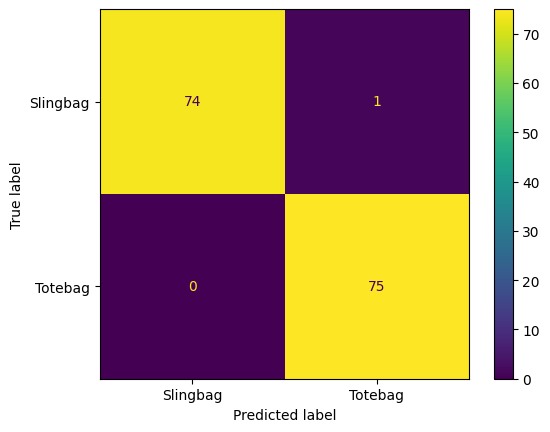

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Slingbag",
        "Totebag"
    ]
)

disp.plot()

plt.show()

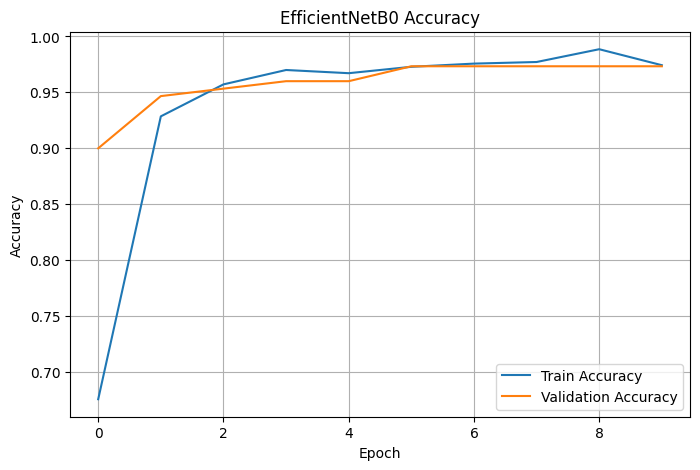

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('EfficientNetB0 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.grid(True)

plt.show()

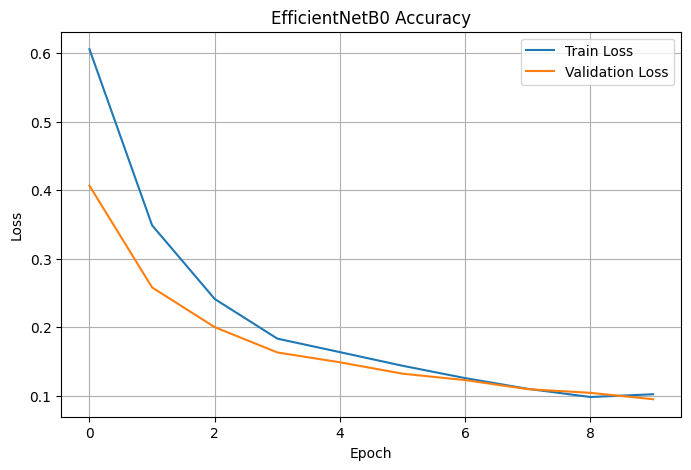

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('EfficientNetB0 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.grid(True)

plt.show()